# 02 Attention Masks
Generazione di maschere binarie dalle mappe di attenzione.

### La Teoria della Maschera (I 3 Passaggi)

Per trasformare i pensieri di FLUX in una maschera utilizzabile per lo Stitching, dobbiamo fare tre operazioni sui tensori:

1.  **La Fusione Semantica:** Siccome il Tokenizer ha spaccato la parola in `"cu"` (Index 3) e `"be"` (Index 4), la prima cosa da fare è sommare matematicamente le loro due mappe per riavere l'intero oggetto.
2.  **La Normalizzazione Min-Max:** I valori crudi dell'attenzione sono numeri piccoli e strani. Li schiacciamo in un range esatto tra 0 e 1 usando la formula classica: 
    $$M_{norm} = \frac{M - \min(M)}{\max(M) - \min(M)}$$
3.  **Il Thresholding (Binarizzazione):** Scegliamo una "Soglia" (es. **0.6**). Tutto ciò che è sopra al 60% di calore diventa **1** (Bianco assoluto), tutto il resto diventa **0** (Nero assoluto).

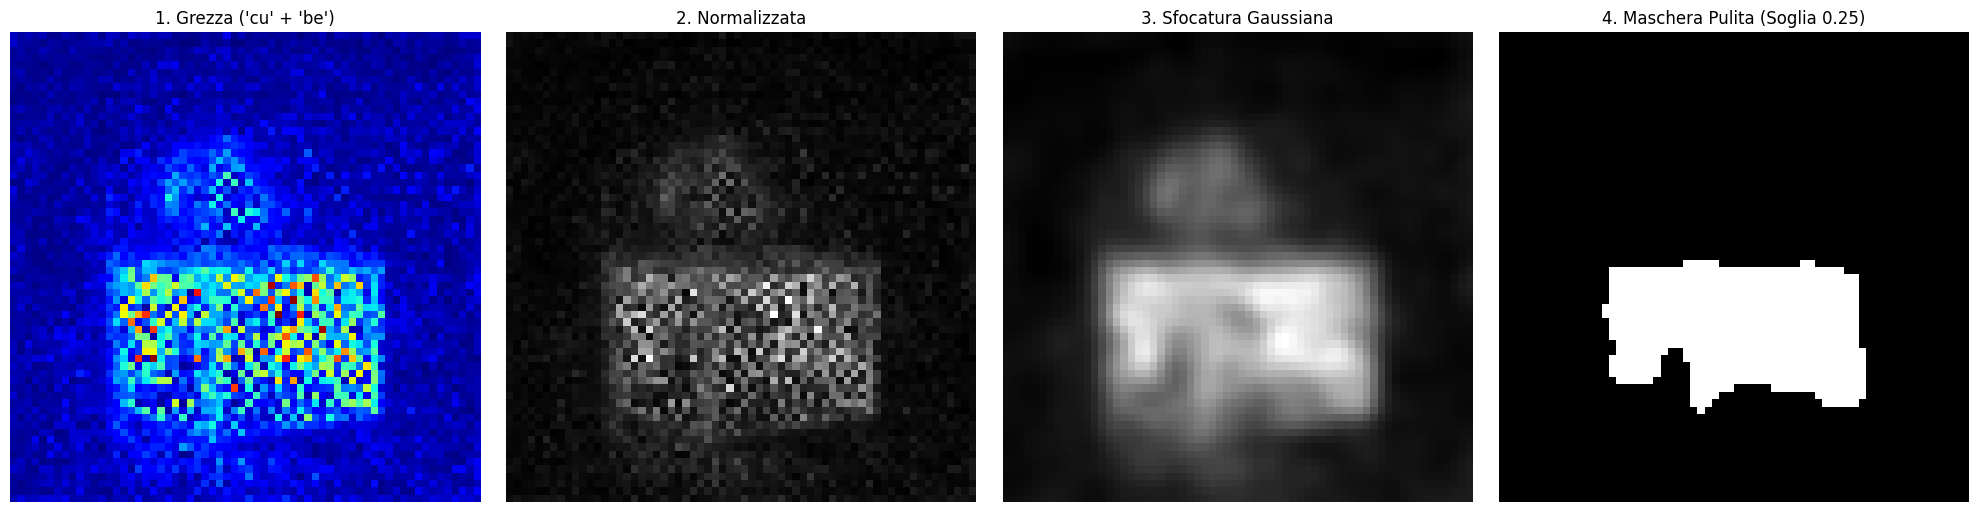

In [24]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

# --- 1. CARICAMENTO DATI ---
percorso_dati = "../data/dataset_v1/a_blue_cube_and_a_red_sphere/" 
attn = torch.load(percorso_dati + "attention_maps.pt", weights_only=True)
layer10 = attn['layer_10']
attn_mean = layer10[0].mean(dim=0)

# --- 2. FUSIONE SEMANTICA ("cu" + "be") ---
# Sommiamo le mappe dalla colonna 2 ('red') fino alla 5 ('<END>') compresa
mappa_cubo_flat = attn_mean[:, 2:5].sum(dim=1) 
mappa_cubo_2d = mappa_cubo_flat.view(64, 64).float()

# --- 3. NORMALIZZAZIONE ---
min_val = mappa_cubo_2d.min()
max_val = mappa_cubo_2d.max()
mappa_norm = (mappa_cubo_2d - min_val) / (max_val - min_val)

# --- 4. IL TRUCCO MAGICO: SFOCATURA GAUSSIANA ---
# Sigma regola la forza della sfocatura. 1.5 è un ottimo punto di partenza per fondere i pixel.
mappa_sfumata = gaussian_filter(mappa_norm.numpy(), sigma=1.5)

# --- 5. BINARIZZAZIONE (Sulla mappa sfumata) ---
# Ora che è sfumata, possiamo usare una soglia media (es. 0.40) e avremo un blocco solido
soglia = 0.25
maschera_binaria = (mappa_sfumata > soglia).astype(float)

# --- 6. VISUALIZZAZIONE ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(mappa_cubo_2d.numpy(), cmap='jet')
axes[0].set_title("1. Grezza ('cu' + 'be')")

axes[1].imshow(mappa_norm.numpy(), cmap='gray')
axes[1].set_title("2. Normalizzata")

# Guardiamo la mappa sfumata prima del taglio
axes[2].imshow(mappa_sfumata, cmap='gray')
axes[2].set_title("3. Sfocatura Gaussiana")

axes[3].imshow(maschera_binaria, cmap='gray')
axes[3].set_title(f"4. Maschera Pulita (Soglia {soglia})")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

🔍 Cerco i token per l'oggetto: 'cu'...
✅ Trovati frammenti: ['cu'] agli indici [3]


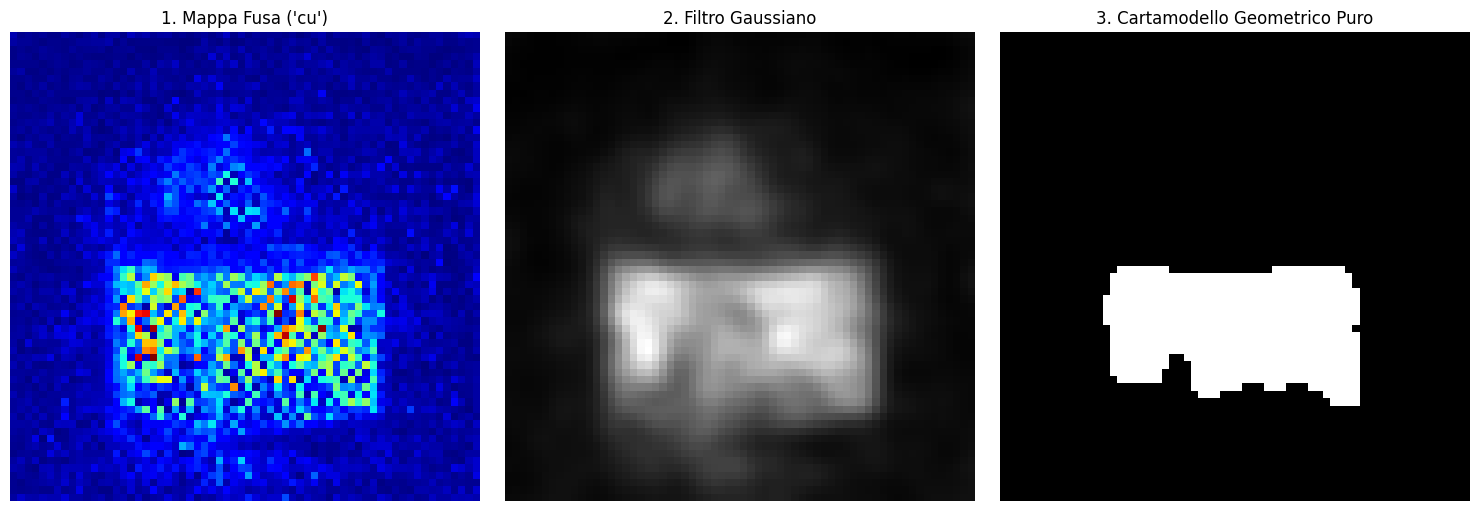

In [26]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from transformers import T5Tokenizer

# --- 1. SETUP E CARICAMENTO ---
percorso_dati = "../data/dataset_v1/a_blue_cube_and_a_red_sphere/" 
prompt = "a red cube and a sphere"
oggetto_target = "cu" # LA MAGIA È QUI: Scegliamo dinamicamente cosa estrarre

# Carichiamo Mappe
attn = torch.load(percorso_dati + "attention_maps.pt", weights_only=True)
attn_mean = attn['layer_10'][0].mean(dim=0)

# Carichiamo Tokenizer
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
tokens = tokenizer(prompt, return_tensors="pt").input_ids[0]

# --- 2. RICERCA DINAMICA DEI TOKEN ---
target_indices = []
frammenti_trovati = []

print(f"🔍 Cerco i token per l'oggetto: '{oggetto_target}'...")
for idx, token_id in enumerate(tokens):
    if token_id.item() == 1: break # Fine frase
    
    # Decodifichiamo e puliamo il frammento (T5 usa il carattere '_' per gli spazi)
    frammento = tokenizer.decode([token_id]).replace(' ', '').strip()
    
    # Se il frammento fa parte della nostra parola target, lo salviamo!
    if frammento and frammento in oggetto_target:
        target_indices.append(idx)
        frammenti_trovati.append(frammento)

print(f"✅ Trovati frammenti: {frammenti_trovati} agli indici {target_indices}")

# --- 3. FUSIONE E MASCHERA (Solo dei token target) ---
# Sommiamo dinamicamente solo gli indici trovati
mappa_target_flat = attn_mean[:, target_indices].sum(dim=1)
mappa_target_2d = mappa_target_flat.view(64, 64).float()

# Normalizzazione
min_val = mappa_target_2d.min()
max_val = mappa_target_2d.max()
mappa_norm = (mappa_target_2d - min_val) / (max_val - min_val)

# Sfocatura e Taglio (Soglia dinamica)
mappa_sfumata = gaussian_filter(mappa_norm.numpy(), sigma=1.5)
soglia = 0.25 # Soglia un po' più alta perché non stiamo mischiando lo sfondo (<END>)
maschera_binaria = (mappa_sfumata > soglia).astype(float)

# --- 4. PLOT ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mappa_target_2d.numpy(), cmap='jet')
axes[0].set_title(f"1. Mappa Fusa ('{'+'.join(frammenti_trovati)}')")

axes[1].imshow(mappa_sfumata, cmap='gray')
axes[1].set_title("2. Filtro Gaussiano")

axes[2].imshow(maschera_binaria, cmap='gray')
axes[2].set_title(f"3. Cartamodello Geometrico Puro")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()